# Continuation output folder — config and plots

Point **`CONTINUATION_DIR`** at a pipeline continuation folder (e.g. `outputs/continuation/no_magnet_<inv_id>/`).

**Interactive plots:** the next code cell selects the **`widget`** backend (`ipympl`). Install with `pip install ipympl`, then **restart the kernel** and run all cells from the top. If `ipympl` is missing, the notebook falls back to static `inline` figures.

That folder should contain reproduction artifacts from `MAGNET_ETAS_pipeline`:
- `original_catalog.csv`, `simulated_catalog.csv`
- `pipeline_config.json`, `inversion_config.json`, `continuation_config.json` (optional `magnet_config.gin`)

**Plots:** **Top:** magnitude vs time (original vs continuation) with `set_times` verticals. **Bottom:** both cumulative step curves (count resets at each `set_times` boundary) on their own panel so continuation is not flattened by the original’s larger counts. **Map:** lon–lat scatter (two colors).

In [ ]:
# Interactive figures (pan / zoom / resize in the notebook).
# Install once in your environment: pip install ipympl
# This cell must run **before** `import matplotlib.pyplot`.
try:
    from IPython import get_ipython

    ip = get_ipython()
    if ip is not None:
        ip.run_line_magic("matplotlib", "widget")
    else:
        raise RuntimeError("No IPython shell")
except Exception as exc:
    import matplotlib

    matplotlib.use("inline")
    print(
        "matplotlib: using non-interactive 'inline' backend. "
        "For pan/zoom install ipympl then re-run this notebook from the top:\n"
        "  pip install ipympl\n",
        f"({type(exc).__name__}: {exc})",
    )


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, Markdown

# --- set this to your continuation output directory ---
CONTINUATION_DIR = Path(
    "/home/neriberman/REPOS/etas_edits/outputs/continuation/no_magnet_c44591a24022c03c"
)

ORIGINAL_NAME = "original_catalog.csv"
SIMULATED_NAME = "simulated_catalog.csv"
PIPELINE_CFG = "pipeline_config.json"
INVERSION_CFG = "inversion_config.json"
CONTINUATION_CFG = "continuation_config.json"
MAGNET_GIN = "magnet_config.gin"


In [2]:
def _load_json(path: Path) -> dict | None:
    if not path.is_file():
        return None
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def _display_json(title: str, data: dict | None) -> None:
    display(Markdown(f"### {title}"))
    if data is None:
        display(Markdown("*missing*"))
        return
    display(Markdown(f"`{title}`"))
    print(json.dumps(data, indent=2, default=str))


root = CONTINUATION_DIR.resolve()
assert root.is_dir(), f"Not a directory: {root}"

paths = {
    "continuation folder": root,
    ORIGINAL_NAME: root / ORIGINAL_NAME,
    SIMULATED_NAME: root / SIMULATED_NAME,
    PIPELINE_CFG: root / PIPELINE_CFG,
    INVERSION_CFG: root / INVERSION_CFG,
    CONTINUATION_CFG: root / CONTINUATION_CFG,
    MAGNET_GIN: root / MAGNET_GIN,
}

display(Markdown("## Files in continuation folder"))
for label, p in paths.items():
    exists = "yes" if p.is_file() or (label == "continuation folder" and p.is_dir()) else "no"
    print(f"- **{label}**: `{p}` ({exists})")

pipeline_cfg = _load_json(paths[PIPELINE_CFG])
inversion_cfg = _load_json(paths[INVERSION_CFG])
continuation_cfg = _load_json(paths[CONTINUATION_CFG])

display(Markdown("## Config used for continuation (reproduction JSON)"))
_display_json("continuation_config.json", continuation_cfg)
_display_json("inversion_config.json", inversion_cfg)
_display_json("pipeline_config.json", pipeline_cfg)

if paths[MAGNET_GIN].is_file():
    display(Markdown("### magnet_config.gin (first 80 lines)"))
    lines = paths[MAGNET_GIN].read_text(encoding="utf-8").splitlines()[:80]
    print("\n".join(lines))
    if len(paths[MAGNET_GIN].read_text(encoding="utf-8").splitlines()) > 80:
        print("\n... [truncated]")


## Files in continuation folder

- **continuation folder**: `/home/neriberman/REPOS/etas_edits/outputs/continuation/no_magnet_c44591a24022c03c` (yes)
- **original_catalog.csv**: `/home/neriberman/REPOS/etas_edits/outputs/continuation/no_magnet_c44591a24022c03c/original_catalog.csv` (yes)
- **simulated_catalog.csv**: `/home/neriberman/REPOS/etas_edits/outputs/continuation/no_magnet_c44591a24022c03c/simulated_catalog.csv` (yes)
- **pipeline_config.json**: `/home/neriberman/REPOS/etas_edits/outputs/continuation/no_magnet_c44591a24022c03c/pipeline_config.json` (yes)
- **inversion_config.json**: `/home/neriberman/REPOS/etas_edits/outputs/continuation/no_magnet_c44591a24022c03c/inversion_config.json` (yes)
- **continuation_config.json**: `/home/neriberman/REPOS/etas_edits/outputs/continuation/no_magnet_c44591a24022c03c/continuation_config.json` (yes)
- **magnet_config.gin**: `/home/neriberman/REPOS/etas_edits/outputs/continuation/no_magnet_c44591a24022c03c/magnet_config.gin` (yes)


## Config used for continuation (reproduction JSON)

### continuation_config.json

`continuation_config.json`

...

### pipeline_config.json

`pipeline_config.json`

{
  "templates": {
    "general_gin_config_path": "/home/neriberman/REPOS/eq_mag_prediction/eq_mag_prediction/forecasting/configs/magnitude_prediction/magnitude_prediction_general.gin",
    "local_gin_config_path": "/home/neriberman/REPOS/eq_mag_prediction/eq_mag_prediction/forecasting/configs/magnitude_prediction/rsqsim_socal.gin",
    "invert_etas_config_json_path": "/home/neriberman/REPOS/etas_edits/config/invert_etas_config.json",
    "etas_catalog_continuation_config_json_path": "/home/neriberman/REPOS/etas_edits/config/simulate_catalog_continuation_config.json"
  },
  "overrides": {
    "set_times": {
      "auxiliary_start": "1971-01-01 00:00:00",
      "timewindow_start": "1981-01-01 00:00:00",
      "timewindow_end": "2007-01-01 00:00:00",
      "testwindow_end": "2021-01-01 00:00:00"
    },
    "simulate_catalog_continuation": {
      "forecast_duration": 1000,
      "magnitude_generator": "simulate_magnitudes",
      "continuation_mode": "classic"
    },
    "catalog": {
   

### magnet_config.gin (first 80 lines)

# CHANGE THE PATH BELOW ACCORDING TO YOUR WORKING DIRECTORY
# or add the following line to your script:
# gin.add_config_file_search_path('relative/or/absolute/path/to/forecasting/configs/magnitude_prediction')
# --- Content from magnitude_prediction_general.gin ---
# Data for experiment
target_catalog:
  catalog = @rsqsim_socal_dataframe()
  separate_repeating_times_in_catalog = True

CatalogDomain:
  train_start_time = 347155200
  validation_start_time = 962496000
  test_start_time = 1167609600
  test_end_time = 1609459200

# Configure the model (and feature) creation and training methods.

build_encoders:
  include_catalog_columns = True
  include_recent_earthquakes = True
  include_biggest_earthquakes = False
  include_seismicity_rate = True

_mock_earthquake.add_angles = %use_moment_angles

SeismicityRateEncoder.prepare_features:
  grid_side_deg = 0.5
  # lookback        = [1hr,12hr, 2d,    10d,   100d,   3yr,     10yr,     30yr]
  lookback_seconds = [3600, 43200, 172800, 864000,


In [3]:
display(Markdown("## Catalog paths (from configs vs reproduction CSVs)"))

if inversion_cfg:
    fc = inversion_cfg.get("fn_catalog")
    sc = inversion_cfg.get("shape_coords")
    dp = inversion_cfg.get("data_path")
    print(f"- **inversion fn_catalog**: `{fc}`")
    print(f"- **inversion shape_coords**: `{sc}`")
    print(f"- **inversion data_path**: `{dp}`")

if continuation_cfg:
    print(f"- **continuation fn_inversion_output**: `{continuation_cfg.get('fn_inversion_output')}`")
    print(f"- **continuation fn_store_simulation**: `{continuation_cfg.get('fn_store_simulation')}`")
    print(f"- **continuation_mode**: `{continuation_cfg.get('continuation_mode')}`")
    print(f"- **magnitude_generator**: `{continuation_cfg.get('magnitude_generator')}`")
    print(f"- **forecast_duration**: `{continuation_cfg.get('forecast_duration')}`")

print(f"- **repro original CSV**: `{paths[ORIGINAL_NAME]}`")
print(f"- **repro simulated CSV**: `{paths[SIMULATED_NAME]}`")


## Catalog paths (from configs vs reproduction CSVs)

- **inversion fn_catalog**: `/home/neriberman/REPOS/etas_edits/input_data/example_catalog.csv`
- **inversion shape_coords**: `/home/neriberman/REPOS/etas_edits/input_data/california_shape.npy`
- **inversion data_path**: `/home/neriberman/REPOS/etas_edits/outputs/inversions/`
- **continuation fn_inversion_output**: `/home/neriberman/REPOS/etas_edits/outputs/inversions/inv_9796573b8dc423fb/parameters_9796573b8dc423fb.json`
- **continuation fn_store_simulation**: `/home/neriberman/REPOS/etas_edits/outputs/continuation/no_magnet_c44591a24022c03c/simulated_catalog.csv`
- **continuation_mode**: `classic`
- **magnitude_generator**: `simulate_magnitudes`
- **forecast_duration**: `1000`
- **repro original CSV**: `/home/neriberman/REPOS/etas_edits/outputs/continuation/no_magnet_c44591a24022c03c/original_catalog.csv`
- **repro simulated CSV**: `/home/neriberman/REPOS/etas_edits/outputs/continuation/no_magnet_c44591a24022c03c/simulated_catalog.csv`


In [4]:
orig_path = paths[ORIGINAL_NAME]
sim_path = paths[SIMULATED_NAME]
assert orig_path.is_file(), f"Missing {orig_path}"
assert sim_path.is_file(), f"Missing {sim_path}"

df_o = pd.read_csv(orig_path)
df_s = pd.read_csv(sim_path)

# normalize column names (ETAS catalogs: id, lat, lon, time, magnitude)
for df, name in ((df_o, "original"), (df_s, "continuation")):
    missing = {"latitude", "longitude", "time", "magnitude"} - set(df.columns)
    if missing:
        raise ValueError(f"{name} missing columns {missing}; have {list(df.columns)}")

df_o = df_o.copy()
df_s = df_s.copy()
df_o["time"] = pd.to_datetime(df_o["time"], utc=True, errors="coerce")
df_s["time"] = pd.to_datetime(df_s["time"], utc=True, errors="coerce")
df_o["magnitude"] = pd.to_numeric(df_o["magnitude"], errors="coerce")
df_s["magnitude"] = pd.to_numeric(df_s["magnitude"], errors="coerce")

print(f"Original rows: {len(df_o)}, continuation rows: {len(df_s)}")


Original rows: 4454, continuation rows: 274


/tmp/ipykernel_8867/1009723471.py:128: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


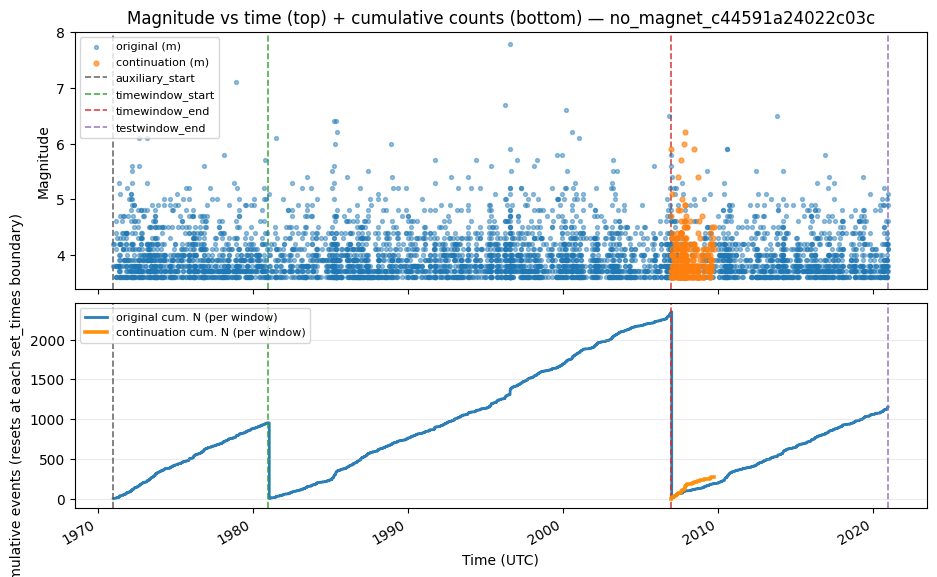

In [7]:
import numpy as np

# Two stacked panels: magnitude uses left axis only; cumulative counts get their own
# vertical scale so the continuation curve is not squashed by the original's larger counts.
fig, (ax_mag, ax_cum) = plt.subplots(
    2,
    1,
    figsize=(11, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [1.25, 1.0], "hspace": 0.06},
)

ax_mag.scatter(
    df_o["time"],
    df_o["magnitude"],
    s=8,
    alpha=0.45,
    c="tab:blue",
    label="original (m)",
    zorder=3,
)
ax_mag.scatter(
    df_s["time"],
    df_s["magnitude"],
    s=12,
    alpha=0.65,
    c="tab:orange",
    label="continuation (m)",
    zorder=3,
)

# Vertical lines: pipeline `overrides.set_times` (fallback: inversion_config same keys)
SET_TIME_KEYS = (
    ("auxiliary_start", "#555555"),
    ("timewindow_start", "#2ca02c"),
    ("timewindow_end", "#d62728"),
    ("testwindow_end", "#9467bd"),
)
_set_times = None
if pipeline_cfg:
    _set_times = pipeline_cfg.get("overrides", {}).get("set_times")
if not _set_times and inversion_cfg:
    _set_times = {k: inversion_cfg[k] for k, _ in SET_TIME_KEYS if k in inversion_cfg}

if _set_times:
    for ax_ in (ax_mag, ax_cum):
        for key, color in SET_TIME_KEYS:
            raw = _set_times.get(key)
            if raw is None or raw == "":
                continue
            ts = pd.to_datetime(raw, utc=True)
            ax_.axvline(
                ts,
                color=color,
                linestyle="--",
                linewidth=1.2,
                alpha=0.85,
                label=key if ax_ is ax_mag else None,
                zorder=2,
            )

# Sorted boundary times for cumulative reset (same keys as vertical lines)
_reset_ts: list = []
if _set_times:
    for key, _ in SET_TIME_KEYS:
        raw = _set_times.get(key)
        if raw is None or raw == "":
            continue
        _reset_ts.append(pd.to_datetime(raw, utc=True))
    _reset_ts = sorted(set(_reset_ts))


def _cumulative_reset_at_times(sorted_times: pd.Series, reset_ts: list) -> np.ndarray:
    """Within each span between sorted ``reset_ts``, count restarts at each boundary (0 then 1,2,...)."""
    if not reset_ts:
        return np.arange(1, len(sorted_times) + 1, dtype=np.int64)
    out = np.zeros(len(sorted_times), dtype=np.int64)
    ri = 0
    cnt = 0
    for k in range(len(sorted_times)):
        tt = sorted_times.iloc[k]
        while ri < len(reset_ts) and tt >= reset_ts[ri]:
            cnt = 0
            ri += 1
        cnt += 1
        out[k] = cnt
    return out


df_o_s = df_o.sort_values("time").reset_index(drop=True)
df_s_s = df_s.sort_values("time").reset_index(drop=True)
n_o = _cumulative_reset_at_times(df_o_s["time"], _reset_ts)
n_s = _cumulative_reset_at_times(df_s_s["time"], _reset_ts)

# Bottom: both cumulative step curves (original first, continuation on top for visibility)
ax_cum.plot(
    df_o_s["time"],
    n_o,
    color="tab:blue",
    linewidth=2.0,
    alpha=0.95,
    drawstyle="steps-post",
    label="original cum. N (per window)",
    zorder=1,
)
ax_cum.plot(
    df_s_s["time"],
    n_s,
    color="darkorange",
    linewidth=2.6,
    alpha=0.95,
    drawstyle="steps-post",
    label="continuation cum. N (per window)",
    zorder=2,
)
ax_cum.set_ylabel("Cumulative events (resets at each set_times boundary)")
ax_cum.grid(True, axis="y", alpha=0.25)
ax_cum.legend(loc="upper left", fontsize=8)

ax_mag.set_ylabel("Magnitude")
ax_mag.set_title(f"Magnitude vs time (top) + cumulative counts (bottom) — {root.name}")
ax_cum.set_xlabel("Time (UTC)")

h1, l1 = ax_mag.get_legend_handles_labels()
ax_mag.legend(h1, l1, loc="upper left", fontsize=8)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()


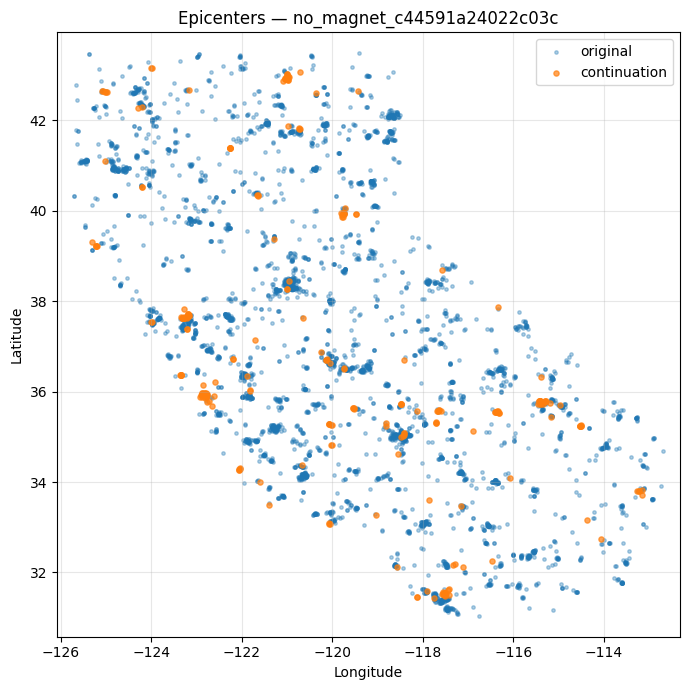

In [6]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(
    df_o["longitude"],
    df_o["latitude"],
    s=6,
    alpha=0.35,
    c="tab:blue",
    label="original",
)
ax.scatter(
    df_s["longitude"],
    df_s["latitude"],
    s=14,
    alpha=0.7,
    c="tab:orange",
    label="continuation",
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Epicenters — {root.name}")
ax.set_aspect("equal", adjustable="datalim")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
